# Data profiling RÚIAN VFR – historie stavebních objektů (OB_UZHZ)

Tento notebook načte XML soubor ve **výměnném formátu RÚIAN (VFR)** typu `OB_UZHZ`
(historie stavebních objektů obce) a provede **data profiling**:

1. Parsování XML a převod jednotlivých entit do `pandas.DataFrame`
2. Přehled struktury (počty záznamů, sloupce, datové typy)
3. Analýza chybějících hodnot
4. Popisné statistiky číselných atributů
5. Frekvenční analýza kódovaných/kategoriálních atributů
6. Analýza časové platnosti záznamů (`PlatiOd` / `PlatiDo`) 
7. Kontrola duplicit a konzistence 
8. Export souhrnné profilovací tabulky do CSV



In [162]:
# --- import knihoven ---

import re
from collections import defaultdict, Counter

import pandas as pd
import matplotlib.pyplot as plt
from lxml import etree

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [163]:
# --- vstupni soubor ---

INPUT_XML = "vfr_Chyne_historicky.xml"

tree = etree.parse(INPUT_XML)
root = tree.getroot()
print("Kořenový element:", etree.QName(root).localname)
print("Namespace mapa:")
for prefix, uri in root.nsmap.items():
    print(f"  {prefix}: {uri}")


Kořenový element: VymennyFormat
Namespace mapa:
  gml: http://www.opengis.net/gml/3.2
  xlink: http://www.w3.org/1999/xlink
  xsi: http://www.w3.org/2001/XMLSchema-instance
  ami: urn:cz:isvs:ruian:schemas:AdrMistoIntTypy:v1
  base: urn:cz:isvs:ruian:schemas:BaseTypy:v1
  coi: urn:cz:isvs:ruian:schemas:CastObceIntTypy:v1
  com: urn:cz:isvs:ruian:schemas:CommonTypy:v1
  kui: urn:cz:isvs:ruian:schemas:KatUzIntTypy:v1
  kri: urn:cz:isvs:ruian:schemas:KrajIntTypy:v1
  mci: urn:cz:isvs:ruian:schemas:MomcIntTypy:v1
  mpi: urn:cz:isvs:ruian:schemas:MopIntTypy:v1
  obi: urn:cz:isvs:ruian:schemas:ObecIntTypy:v1
  oki: urn:cz:isvs:ruian:schemas:OkresIntTypy:v1
  opi: urn:cz:isvs:ruian:schemas:OrpIntTypy:v1
  pai: urn:cz:isvs:ruian:schemas:ParcelaIntTypy:v1
  pui: urn:cz:isvs:ruian:schemas:PouIntTypy:v1
  rsi: urn:cz:isvs:ruian:schemas:RegSouIntiTypy:v1
  spi: urn:cz:isvs:ruian:schemas:SpravObvIntTypy:v1
  sti: urn:cz:isvs:ruian:schemas:StatIntTypy:v1
  soi: urn:cz:isvs:ruian:schemas:StavObjIntTy

In [164]:
# --- hlavicka souboru ---

NS = root.nsmap.copy()
NS_VF = NS.get("vf")

hlavicka = root.find("vf:Hlavicka", NS)
hlavicka_info = {etree.QName(c).localname: c.text for c in hlavicka if c.tag is not etree.Comment}
for k, v in hlavicka_info.items():
    print(f"{k:20s}: {v}")


VerzeVFR            : 3.1
TypZaznamu          : Historie
TypDavky            : Plna
TypSouboru          : OB_UZHZ
Datum               : 2026-07-01T00:01:04
Metadata            : None


## 1. Parsování XML a převod jednotlivých entit do `pandas.DataFrame`

RÚIAN VFR má jednoduché či vnořené textové elementy.

Funkce `flatten_element` níže tuto strukturu obecně "zplošťuje" do slovníku
`{sloupec: hodnota}`, včetně ošetření:
- opakujících se elementů (víc čísel domovních, víc parcel) → spojení do textu + počet,
- prázdných/chybějících hodnot → `None`,
- GML geometrie → rozbalená na souřadnice 


In [165]:
# --- funkce na parsovani ---

def local(tag):
    """Vrátí lokální jméno elementu bez namespace."""
    return etree.QName(tag).localname

GML_NS = "{http://www.opengis.net/gml/3.2}"


def parse_gml_point(el):
    """Pokud element obsahuje gml:Point, vrátí jeho WKT, jinak None."""
    pt = el.find(f".//{GML_NS}Point")
    if pt is None:
        return None
    pos = pt.find(f"{GML_NS}pos")
    if pos is None or not pos.text:
        return None
    parts = pos.text.strip().split()
    if len(parts) >= 2:
        try:
            x = float(parts[0])
            y = float(parts[1])
            return f"POINT ({x} {y})"
        except ValueError:
            return None
    return None


def flatten_element(el, prefix=""):
    """Obecné zplošťení jednoho XML elementu do plochého slovníku."""
    result = {}
    children = [c for c in el if isinstance(c.tag, str)]

    if not children:
        text = (el.text or "").strip()
        return {prefix: text if text else None}

    groups = defaultdict(list)
    for c in children:
        groups[local(c.tag)].append(c)

    for tag, els in groups.items():
        key = f"{prefix}.{tag}" if prefix else tag

        if tag == "Geometrie":
            wkt = parse_gml_point(els[0])
            result[f"{key}"] = wkt
            continue

        if len(els) == 1:
            c = els[0]
            sub_children = [x for x in c if isinstance(x.tag, str)]
            if not sub_children:
                text = (c.text or "").strip()
                result[key] = text if text else None
            else:
                result.update(flatten_element(c, key))
        else:
            leaf_all = all(not [x for x in c if isinstance(x.tag, str)] for c in els)
            if leaf_all:
                texts = [(c.text or "").strip() for c in els]
                result[key] = "; ".join(t for t in texts if t) or None
            else:
                flat_each = [flatten_element(c, key) for c in els]
                merged = defaultdict(list)
                for fd in flat_each:
                    for kk, vv in fd.items():
                        merged[kk].append("" if vv is None else str(vv))
                for kk, vv in merged.items():
                    result[kk] = "; ".join(x for x in vv if x) or None

    return result


def elements_to_df(elements, id_field=None):
    """Převede seznam lxml elementů na pandas DataFrame pomocí flatten_element."""
    rows = []
    for el in elements:
        row = flatten_element(el)
        row["_gml_id"] = el.get(f"{GML_NS}id")
        rows.append(row)
    df = pd.DataFrame(rows)
    return df

print("Parser připraven.")

Parser připraven.


In [166]:
# --- zjisteni dostupnych kolekci a cest k nim---

data_el = root.find("vf:Data", NS)
collections = [etree.QName(child).localname for child in data_el]

print("Dostupné kolekce v vf:Data:")
for name in collections:
    print(f"- {name}")

print("\nVygenerované entity_paths:")
entity_paths = {}

for collection in data_el:
    coll_name = etree.QName(collection).localname
    if len(collection) > 0:
        child_name = etree.QName(collection[0]).localname
        entity_paths[coll_name] = f"vf:{coll_name}/vf:{child_name}"
        print(f"{coll_name}: vf:{coll_name}/vf:{child_name}")



Dostupné kolekce v vf:Data:
- Obce
- CastiObci
- Zsj
- Ulice
- StavebniObjekty
- AdresniMista

Vygenerované entity_paths:
Obce: vf:Obce/vf:Obec
CastiObci: vf:CastiObci/vf:CastObce
Zsj: vf:Zsj/vf:Zsj
Ulice: vf:Ulice/vf:Ulice
StavebniObjekty: vf:StavebniObjekty/vf:StavebniObjekt
AdresniMista: vf:AdresniMista/vf:AdresniMisto


In [167]:
# --- extrakce elementu do DataFrame ---

dfs = {}
for name, path in entity_paths.items():
    els = data_el.findall(path, NS)
    if not els:
        continue
    dfs[name] = elements_to_df(els)
    print(f"{name:20s} {len(els):6d} záznamů  |  {dfs[name].shape[1]:3d} atributů")

df_so   = dfs.get("StavebniObjekty")
df_ami  = dfs.get("AdresniMista")
df_ulice = dfs.get("Ulice")
df_obce = dfs.get("Obce")


Obce                      3 záznamů  |   17 atributů
CastiObci                 1 záznamů  |    7 atributů
Zsj                       6 záznamů  |   10 atributů
Ulice                   279 záznamů  |    8 atributů
StavebniObjekty        2108 záznamů  |   24 atributů
AdresniMista           2055 záznamů  |   10 atributů


## 2. Přehled struktury dat

Pro každou entitu: tvar tabulky, seznam sloupců a datové typy

In [168]:
for name, df in dfs.items():
    print(f"=== {name}: {len(df)} záznamů, {len(df.columns)} atributů ===")
    print(list(df.columns))
    try:
        display(df.dtypes.rename("dtype").to_frame())
    except Exception:
        print(df.dtypes)
    print()

=== Obce: 3 záznamů, 17 atributů ===
['Kod', 'Nazev', 'StatusKod', 'Okres.Kod', 'Pou.Kod', 'PlatiOd', 'PlatiDo', 'GlobalniIdNavrhuZmeny', 'VlajkaText', 'ZnakText', 'NutsLau', '_gml_id', 'MluvnickeCharakteristiky.Pad2', 'MluvnickeCharakteristiky.Pad3', 'MluvnickeCharakteristiky.Pad4', 'MluvnickeCharakteristiky.Pad6', 'MluvnickeCharakteristiky.Pad7']


,dtype
Kod,str
Nazev,str
StatusKod,str
Okres.Kod,str
Pou.Kod,str
PlatiOd,str
PlatiDo,str
GlobalniIdNavrhuZmeny,str
VlajkaText,str
ZnakText,str



=== CastiObci: 1 záznamů, 7 atributů ===
['Kod', 'Nazev', 'Obec.Kod', 'PlatiOd', 'PlatiDo', 'GlobalniIdNavrhuZmeny', '_gml_id']


,dtype
Kod,str
Nazev,str
Obec.Kod,str
PlatiOd,str
PlatiDo,str
GlobalniIdNavrhuZmeny,str
_gml_id,str



=== Zsj: 6 záznamů, 10 atributů ===
['Kod', 'Nazev', 'KatastralniUzemi.Kod', 'PlatiOd', 'PlatiDo', 'GlobalniIdNavrhuZmeny', 'Vymera', 'CharakterZsjKod', 'DatumVzniku', '_gml_id']


...

,dtype
Kod,str
Nazev,str
Obec.Kod,str
PlatiOd,str
PlatiDo,str
GlobalniIdNavrhuZmeny,str
_gml_id,str
Geometrie,float64



=== StavebniObjekty: 2108 záznamů, 24 atributů ===
['Kod', 'CislaDomovni.CisloDomovni', 'IdentifikacniParcela.Id', 'TypStavebnihoObjektuKod', 'ZpusobVyuzitiKod', 'CastObce.Kod', 'PlatiOd', 'PlatiDo', 'GlobalniIdNavrhuZmeny', 'PocetBytu', 'PripojeniKanalizaceKod', 'PripojeniPlynKod', 'PripojeniVodovodKod', 'ZpusobVytapeniKod', '_gml_id', 'DruhKonstrukceKod', 'PocetPodlazi', 'VybaveniVytahemKod', 'Geometrie', 'IsknBudovaId', 'ZastavenaPlocha', 'Dokonceni', 'ObestavenyProstor', 'PodlahovaPlocha']


,dtype
Kod,str
CislaDomovni.CisloDomovni,str
IdentifikacniParcela.Id,str
TypStavebnihoObjektuKod,str
ZpusobVyuzitiKod,str
CastObce.Kod,str
PlatiOd,str
PlatiDo,str
GlobalniIdNavrhuZmeny,str
PocetBytu,str



=== AdresniMista: 2055 záznamů, 10 atributů ===
['Kod', 'CisloDomovni', 'Psc', 'StavebniObjekt.Kod', 'Ulice.Kod', 'PlatiOd', 'PlatiDo', 'GlobalniIdNavrhuZmeny', '_gml_id', 'Geometrie']


,dtype
Kod,str
CisloDomovni,str
Psc,str
StavebniObjekt.Kod,str
Ulice.Kod,str
PlatiOd,str
PlatiDo,str
GlobalniIdNavrhuZmeny,str
_gml_id,str
Geometrie,str


##  Datové typy a úprava 


Většina stavebně-technických atributů načtených ze surového VFR/XML souboru je reprezentována jako **řetězec (string)**.


* **Přetypování na čísla:** Počty podlaží, počty bytů aj. převést na celé/desetinné číslo (`int` / `float`).
* **Přetypování na datumy:** Časová razítka (`Dokončení`, `PlatiOd`, `PlatiDo`) převést na datový typ datetime (`YYYY-MM-DD`).


### Časové atributy budov


**`Dokončení`** 
- Fyzický vznik budovy (rok/datum postavení a kolaudace)
- Nemění se v čase 


**`PlatiOd`** / **`PlatiDo`** 
- Platnost databázového záznamu v RÚIAN.
- Mění se automaticky při jakékoliv úpravě atributů či geometrie 
- Slouží pro verzování databáze 




In [169]:
NUMERIC_HINTS = (
    "PocetBytu",
    "PocetPodlazi",
    "ZastavenaPlocha",
    "ObestavenyProstor",
    "PodlahovaPlocha",
    "Plocha",
    "Pocet",
    "_pocet",
)
DATE_HINTS = (
    "PlatiOd",
    "PlatiDo",
    "Dokonceni",
)

def coerce_types(df):
    df = df.copy()
    for col in df.columns:
        if any(col.endswith(h) or col == h for h in DATE_HINTS):
            df[col] = pd.to_datetime(df[col], errors="coerce")
        elif any(col.endswith(h) or col == h for h in NUMERIC_HINTS):
            converted = pd.to_numeric(df[col], errors="coerce")
            non_null = df[col].notna().sum()
            if non_null and converted.notna().sum() / non_null > 0.9:
                df[col] = converted
    return df

if df_so is not None:
    df_so = coerce_types(df_so)
    dfs["StavebniObjekty"] = df_so

print(f"=== StavebniObjekty — tvar {df_so.shape} ===")
display(df_so.dtypes.rename("dtype").to_frame())


=== StavebniObjekty — tvar (2108, 24) ===


,dtype
Kod,str
CislaDomovni.CisloDomovni,str
IdentifikacniParcela.Id,str
TypStavebnihoObjektuKod,str
ZpusobVyuzitiKod,str
CastObce.Kod,str
PlatiOd,datetime64[us]
PlatiDo,datetime64[us]
GlobalniIdNavrhuZmeny,str
PocetBytu,float64


### Náhled dat – Stavební objekty 

In [170]:
df_so.head(10)


,Kod,CislaDomovni.CisloDomovni,IdentifikacniParcela.Id,TypStavebnihoObjektuKod,ZpusobVyuzitiKod,CastObce.Kod,PlatiOd,PlatiDo,GlobalniIdNavrhuZmeny,PocetBytu,PripojeniKanalizaceKod,PripojeniPlynKod,PripojeniVodovodKod,ZpusobVytapeniKod,_gml_id,DruhKonstrukceKod,PocetPodlazi,VybaveniVytahemKod,Geometrie,IsknBudovaId,ZastavenaPlocha,Dokonceni,ObestavenyProstor,PodlahovaPlocha
0,6398332,1,1304146210,1,3,55468,2011-07-01,2013-11-19,0,1.0,8,8,9,9,SO.6398332.20110701,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,6398332,1,1304146210,1,7,55468,2022-05-30,2023-12-22,2787538,1.0,1,9,1,9,SO.6398332.20220530,10,1.0,9,NaN,NaN,NaN,NaT,NaN,NaN
2,6398332,1,1304146210,1,3,55468,2013-11-20,2022-05-29,456855,1.0,1,9,1,9,SO.6398332.20131120,10,1.0,9,NaN,NaN,NaN,NaT,NaN,NaN
3,6398341,2,1304149210,1,7,55468,2011-07-01,2013-11-19,0,2.0,3,3,1,1,SO.6398341.20110701,NaN,NaN,2,POINT (-756761.77 -1044034.95),NaN,NaN,NaT,NaN,NaN
4,6398341,2,1304149210,1,7,55468,2016-04-05,2023-12-22,905764,2.0,1,3,1,1,SO.6398341.20160405,10,1.0,2,NaN,NaN,NaN,NaT,NaN,NaN
5,6398341,2,1304149210,1,7,55468,2013-11-20,2016-04-04,456855,2.0,1,3,1,1,SO.6398341.20131120,10,1.0,2,NaN,NaN,NaN,NaT,NaN,NaN
6,6398359,3,1304151210,1,3,55468,2011-07-01,2013-11-19,0,2.0,3,3,1,1,SO.6398359.20110701,NaN,NaN,2,NaN,NaN,NaN,NaT,NaN,NaN
7,6398359,3,1304151210,1,7,55468,2022-05-30,2023-12-22,2787538,2.0,1,1,1,1,SO.6398359.20220530,10,1.0,2,NaN,NaN,NaN,NaT,NaN,NaN
8,6398359,3,1304151210,1,3,55468,2013-11-20,2022-05-29,456855,2.0,1,1,1,1,SO.6398359.20131120,10,1.0,2,NaN,NaN,NaN,NaT,NaN,NaN
9,6398367,4,1304152210,1,3,55468,2011-07-01,2013-11-19,0,1.0,3,3,1,1,SO.6398367.20110701,NaN,NaN,2,POINT (-756804.87 -1044074.56),NaN,NaN,NaT,NaN,NaN


## 3. Analýza chybějících hodnot (stavební objekty)

Pro každý sloupec spočítáme počet a procento chybějících (`NaN`/`None`)
hodnot

In [171]:
def missing_report(df, name):
    total = len(df)
    miss = df.isna().sum().sort_values(ascending=False)
    pct = round(miss / total * 100, 1)
    rep = pd.DataFrame({"chybi_pocet": miss, "chybi_procent": pct,
                         "vyplneno_pocet": total - miss})
    rep = rep[rep["chybi_pocet"] >= 0]
    print(f"--- {name} (celkem {total} záznamů) ---")
    return rep

missing_so = missing_report(df_so, "StavebniObjekty")
missing_so


--- StavebniObjekty (celkem 2108 záznamů) ---


,chybi_pocet,chybi_procent,vyplneno_pocet
IsknBudovaId,2106,99.9,2
Geometrie,1788,84.8,320
Dokonceni,965,45.8,1143
PodlahovaPlocha,885,42.0,1223
ObestavenyProstor,818,38.8,1290
ZastavenaPlocha,744,35.3,1364
DruhKonstrukceKod,587,27.8,1521
VybaveniVytahemKod,556,26.4,1552
PocetPodlazi,404,19.2,1704
PripojeniPlynKod,234,11.1,1874


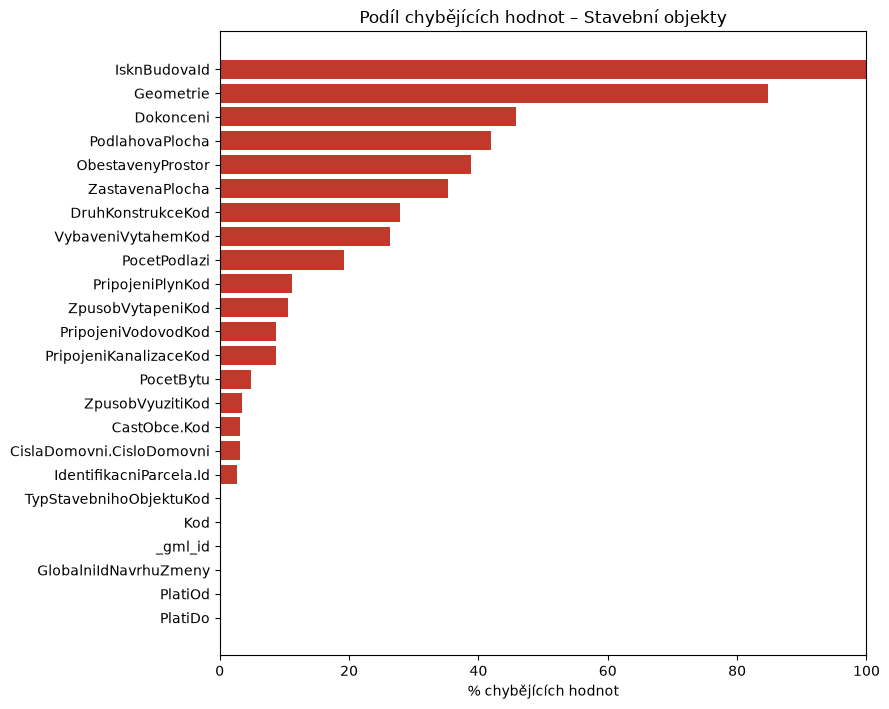

In [172]:
# Vizualizace chybějících hodnot pro stavební objekty
fig, ax = plt.subplots(figsize=(9, max(4, len(missing_so) * 0.3)))
plot_data = missing_so.sort_values("chybi_procent")
ax.barh(plot_data.index, plot_data["chybi_procent"], color="#c0392b")
ax.set_xlabel("% chybějících hodnot")
ax.set_title("Podíl chybějících hodnot – Stavební objekty")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


In [173]:
# --- agregace na jednu řádku per stavební objekt (Kod) ---
# Geometrie a Dokonceni se považují za vyplněné, pokud jsou přítomné v alespoň jedné verzi

kod_col = "Kod" if "Kod" in df_so.columns else next(c for c in df_so.columns if c.endswith(".Kod"))

geom_col = next((c for c in df_so.columns if c == "Geometrie" or c.endswith(".Geometrie")), None)
dok_col = next((c for c in df_so.columns if c == "Dokonceni" or c.endswith(".Dokonceni")), None)

obj_summary = pd.DataFrame({
    "pocet_verzi": df_so.groupby(kod_col, dropna=False).size()
})
obj_summary.index.name = kod_col
obj_summary = obj_summary.reset_index()

if geom_col is not None:
    geom_present = (
        df_so.groupby(kod_col, dropna=False)[geom_col]
        .apply(lambda s: s.notna().any())
        .rename("geometrie_v_alespon_jedne_verzi")
    )
    obj_summary = obj_summary.merge(geom_present.reset_index(), on=kod_col, how="left")
else:
    obj_summary["geometrie_v_alespon_jedne_verzi"] = False

if dok_col is not None:
    dok_present = (
        df_so.groupby(kod_col, dropna=False)[dok_col]
        .apply(lambda s: s.notna().any())
        .rename("dokonceni_v_alespon_jedne_verzi")
    )
    obj_summary = obj_summary.merge(dok_present.reset_index(), on=kod_col, how="left")
else:
    obj_summary["dokonceni_v_alespon_jedne_verzi"] = False

obj_summary["geometrie_v_alespon_jedne_verzi"] = obj_summary["geometrie_v_alespon_jedne_verzi"].fillna(False).astype(bool)
obj_summary["dokonceni_v_alespon_jedne_verzi"] = obj_summary["dokonceni_v_alespon_jedne_verzi"].fillna(False).astype(bool)


print("Počet stavebních objektů:", len(obj_summary))
print("\nS geometrií v alespoň jedné verzi:", int(obj_summary["geometrie_v_alespon_jedne_verzi"].sum()), "(", round(int(obj_summary["geometrie_v_alespon_jedne_verzi"].sum()) / len(obj_summary) * 100, 1), "% )")
print("Bez geometrie ve všech verzích:", int((~obj_summary["geometrie_v_alespon_jedne_verzi"]).sum()), "( chybí", round(int((~obj_summary["geometrie_v_alespon_jedne_verzi"]).sum()) / len(obj_summary) * 100, 1), "% )")
print("\nS dokončením v alespoň jedné verzi:", int(obj_summary["dokonceni_v_alespon_jedne_verzi"].sum()), "(", round(int(obj_summary["dokonceni_v_alespon_jedne_verzi"].sum()) / len(obj_summary) * 100, 1), "%)")
print("Bez dokončení ve všech verzích:", int((~obj_summary["dokonceni_v_alespon_jedne_verzi"]).sum()), "( chybí", round(int((~obj_summary["dokonceni_v_alespon_jedne_verzi"]).sum()) / len(obj_summary) * 100, 1), "% )")


obj_summary.head(10)


Počet stavebních objektů: 1112

S geometrií v alespoň jedné verzi: 277 ( 24.9 % )
Bez geometrie ve všech verzích: 835 ( chybí 75.1 % )

S dokončením v alespoň jedné verzi: 749 ( 67.4 %)
Bez dokončení ve všech verzích: 363 ( chybí 32.6 % )


,Kod,pocet_verzi,geometrie_v_alespon_jedne_verzi,dokonceni_v_alespon_jedne_verzi
0,100687661,1,False,True
1,100788971,1,True,True
2,100983537,1,False,True
3,101420111,1,False,True
4,101498659,2,True,True
5,101498837,2,True,True
6,101498900,3,True,True
7,101533896,2,False,True
8,102260923,1,False,True
9,102344523,2,False,True


In [174]:
# Stejná analýza pro ostatní entity
for name, df in dfs.items():
    if name == "StavebniObjekty":
        continue
    print(missing_report(df, name))
    print()


--- Obce (celkem 3 záznamů) ---
                               chybi_pocet  chybi_procent  vyplneno_pocet
MluvnickeCharakteristiky.Pad3            1           33.3               2
MluvnickeCharakteristiky.Pad2            1           33.3               2
MluvnickeCharakteristiky.Pad4            1           33.3               2
MluvnickeCharakteristiky.Pad6            1           33.3               2
MluvnickeCharakteristiky.Pad7            1           33.3               2
Kod                                      0            0.0               3
Nazev                                    0            0.0               3
Okres.Kod                                0            0.0               3
StatusKod                                0            0.0               3
VlajkaText                               0            0.0               3
GlobalniIdNavrhuZmeny                    0            0.0               3
PlatiDo                                  0            0.0               3
PlatiO

## 4. Popisné statistiky číselných atributů

Např. zastavěná plocha, obestavěný prostor, podlahová plocha, počet bytů,
počet podlaží a rok dokončení.

In [175]:
# Identifikace číselných a kategoriálních sloupců
numeric_cols = df_so.select_dtypes(include=['number']).columns.tolist()

print("Číselné sloupce:", numeric_cols)



Číselné sloupce: ['PocetBytu', 'PocetPodlazi', 'ZastavenaPlocha', 'ObestavenyProstor', 'PodlahovaPlocha']


In [176]:
# Popisné statistiky pro číselné sloupce
desc = df_so[numeric_cols].describe()
desc.loc["chybi_procent"] = round(df_so[numeric_cols].isna().mean() * 100, 1)

if "Dokonceni" in df_so.columns:
    dok_year = pd.to_datetime(df_so["Dokonceni"], errors="coerce").dt.year
    desc["Dokonceni_rok"] = dok_year.describe().round(1)
    desc.loc["chybi_procent", "Dokonceni_rok"] = round(dok_year.isna().mean() * 100, 1)

desc = desc.round(2)
desc


,PocetBytu,PocetPodlazi,ZastavenaPlocha,ObestavenyProstor,PodlahovaPlocha,Dokonceni_rok
count,2006.00,1704.00,1364.00,1290.00,1223.00,1143.0
mean,1.86,1.99,154.29,1110.65,267.80,2012.6
std,5.06,3.95,191.99,2523.25,498.42,8.6
min,0.00,1.00,5.00,17.00,4.00,1900.0
25%,1.00,1.00,86.00,476.00,130.00,2007.0
50%,1.00,2.00,119.00,635.00,163.00,2012.0
75%,1.00,2.00,175.00,947.00,220.00,2019.0
max,110.00,162.00,2860.00,43222.00,9237.00,2025.0
chybi_procent,4.80,19.20,35.30,38.80,42.00,45.8


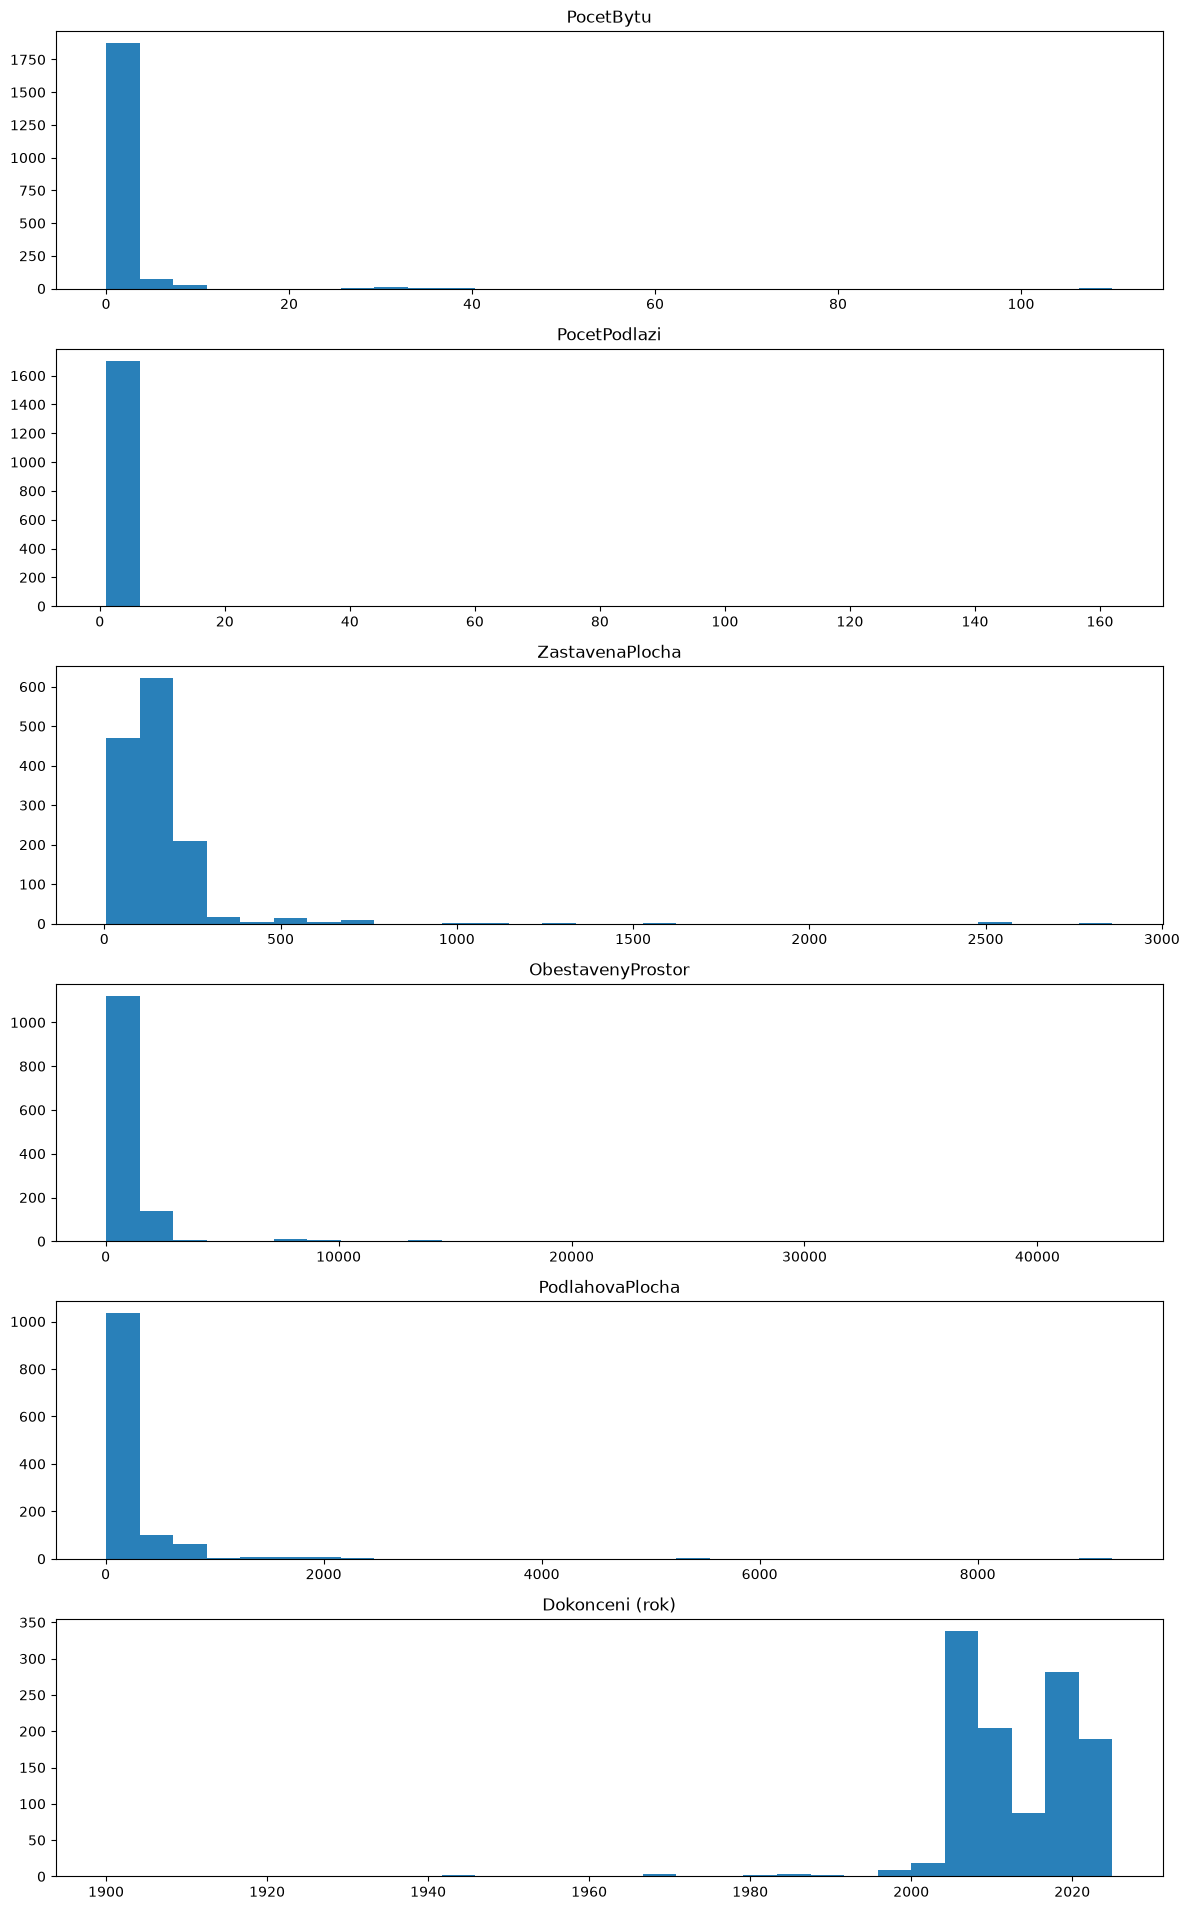

In [177]:
# Histogramy pro hlavní kvantitativní atributy budov

n = len(numeric_cols) + (1 if "Dokonceni" in df_so.columns else 0)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    data = df_so[col].dropna()
    ax.hist(data, bins=30, color="#2980b9")
    ax.set_title(col.split(".")[-1])
if "Dokonceni" in df_so.columns:
    ax = axes[-1]
    data = df_so["Dokonceni"].dropna().dt.year
    ax.hist(data, bins=30, color="#2980b9")
    ax.set_title("Dokonceni (rok)")

plt.tight_layout()
plt.show()


## 5. Frekvenční analýza kódovaných (kategoriálních) atributů

RÚIAN používá číselníkové kódy (např. způsob vytápění, typ konstrukce,
napojení na sítě). Význam kódů zjistíme z příslušných číselníků ČÚZK.

In [185]:
categorical_cols = ["TypStavebnihoObjektuKod", "ZpusobVyuzitiKod", "DruhKonstrukceKod"]

# --- načtení číselníků a přidání popisů kódovaných atributů ---
lookup_sources = {
    "TypStavebnihoObjektuKod": "ciselniky/CS_TYP_STAVEBNIHO_OBJEKTU.csv",
    "ZpusobVyuzitiKod": "ciselniky/CE_ZPUSOB_VYUZITI_OBJEKTU.csv",
    "DruhKonstrukceKod": "ciselniky/CE_DRUH_KONSTRUKCE.csv",
}


def repair_cp1250_text(value):
    if not isinstance(value, str):
        return value
    try:
        return value.encode("latin1").decode("cp1250")
    except Exception:
        return value

for col, csv_path in lookup_sources.items():
    if col not in df_so.columns:
        print(f"Sloupec {col} není v df_so; přeskočeno.")
        continue

    try:
        lookup_df = pd.read_csv(csv_path, sep=";", encoding="utf-8-sig")
    except UnicodeDecodeError:
        lookup_df = pd.read_csv(csv_path, sep=";", encoding="latin1")

    if "KOD" not in lookup_df.columns:
        print(f"Soubor {csv_path} neobsahuje sloupec KOD.")
        continue

    lookup_df["KOD"] = lookup_df["KOD"].astype(str).str.strip()
    lookup_df["NAZEV"] = lookup_df["NAZEV"].astype(str).str.strip().apply(repair_cp1250_text)
    lookup_df = lookup_df.drop_duplicates(subset=["KOD"], keep="first")

    desc_col = f"{col}_desc"
    df_so[col] = df_so[col].astype("string").str.strip()
    lookup_map = dict(zip(lookup_df["KOD"], lookup_df["NAZEV"]))
    df_so[desc_col] = df_so[col].map(lookup_map)


# Frekvenční analýza kódovaných atributů s popisy
for col in categorical_cols:
    if col not in df_so.columns:
        continue
    desc_col = f"{col}_desc"
    vc = (
        df_so.groupby([col, desc_col])
        .size()
        .reset_index(name="pocet")
        .sort_values("pocet", ascending=False)
        .head(20)
    )
    print(f"\n--- {col} s popisem ---")
    display(vc)



--- TypStavebnihoObjektuKod s popisem ---


,TypStavebnihoObjektuKod,TypStavebnihoObjektuKod_desc,pocet
0,1,budova s číslem popisným,2014
2,3,budova bez č.p. /č.ev.,65
1,2,budova s číslem evidenčním,29



--- ZpusobVyuzitiKod s popisem ---


,ZpusobVyuzitiKod,ZpusobVyuzitiKod_desc,pocet
14,7,rodinný dům,1489
11,3,objekt k bydlení,273
13,6,bytový dům,139
9,19,jiná stavba,29
12,5,objekt občanské vybavenosti,20
8,18,garáž,19
15,8,stavba pro rodinnou rekreaci,16
6,15,stavba občanského vybavení,12
4,13,zemědělská stavba,12
7,16,stavba technického vybavení,6



--- DruhKonstrukceKod s popisem ---


,DruhKonstrukceKod,DruhKonstrukceKod_desc,pocet
0,1,"Cihly, tvárnice, cihlové bloky",757
1,10,"Kámen, cihly, tvárnice vč. kombinací",438
5,6,Dřevo,103
7,9,Nezjištěno,80
4,4,Stěnové panely,79
6,7,Jiné materiály a kombinace,51
3,2,Kámen,11
2,11,Monolit,2


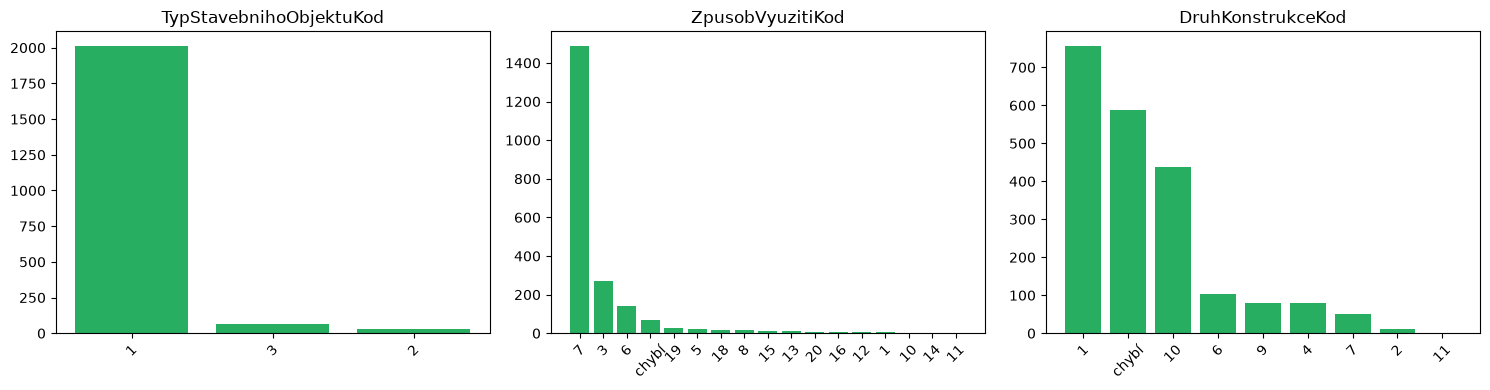

In [187]:
# Grafické znázornění 
key_cat = [c for c in categorical_cols if c in df_so.columns]
fig, axes = plt.subplots(1, len(key_cat), figsize=(5 * len(key_cat), 4))
if len(key_cat) == 1:
    axes = [axes]
for ax, col in zip(axes, key_cat):
    vc = df_so[col].value_counts(dropna=False)
    labels = [("chybí" if pd.isna(v) else str(v)) for v in vc.index]
    ax.bar(labels, vc.values, color="#27ae60")
    ax.set_title(col.split(".")[-1])
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 6. Analýza časové platnosti (`PlatiOd` / `PlatiDo`)

Soubor je typu **Historie**, tzn. jeden stavební objekt (identifikovaný `Kod`)
se může v souboru objevit vícekrát – jednou pro každé období platnosti
(verzi) svých atributů.

In [188]:
platiOd_col = [c for c in df_so.columns if c.endswith("PlatiOd")][0]
platiDo_col = [c for c in df_so.columns if c.endswith("PlatiDo")][0]
kod_col = "Kod" if "Kod" in df_so.columns else [c for c in df_so.columns if c.endswith(".Kod")][0]

print("Celkový počet řádků (verzí):", len(df_so))
print("Počet unikátních stavebních objektů (Kod):", df_so[kod_col].nunique())
print("Průměrný počet verzí na objekt: %.2f" %
      (len(df_so) / df_so[kod_col].nunique()))

verze_na_objekt = df_so.groupby(kod_col).size().value_counts().sort_index()
print("\nRozdělení počtu verzí na objekt:")
print(verze_na_objekt)


Celkový počet řádků (verzí): 2108
Počet unikátních stavebních objektů (Kod): 1112
Průměrný počet verzí na objekt: 1.90

Rozdělení počtu verzí na objekt:
1    447
2    433
3    152
4     64
5     13
6      3
Name: count, dtype: int64


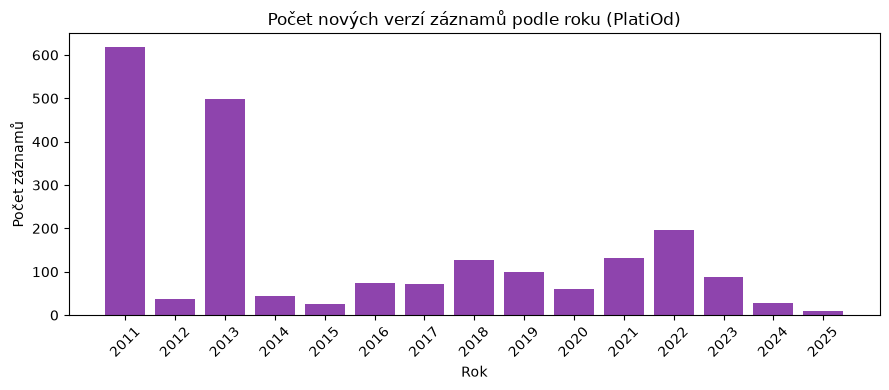

In [189]:
# Časové rozložení začátků platnosti (kdy vznikaly / se měnily záznamy)
platnost_od_rok = df_so[platiOd_col].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(platnost_od_rok.index.astype(str), platnost_od_rok.values, color="#8e44ad")
ax.set_title("Počet nových verzí záznamů podle roku (PlatiOd)")
ax.set_xlabel("Rok")
ax.set_ylabel("Počet záznamů")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Počet aktuálně platných stavebních objektů: 1112


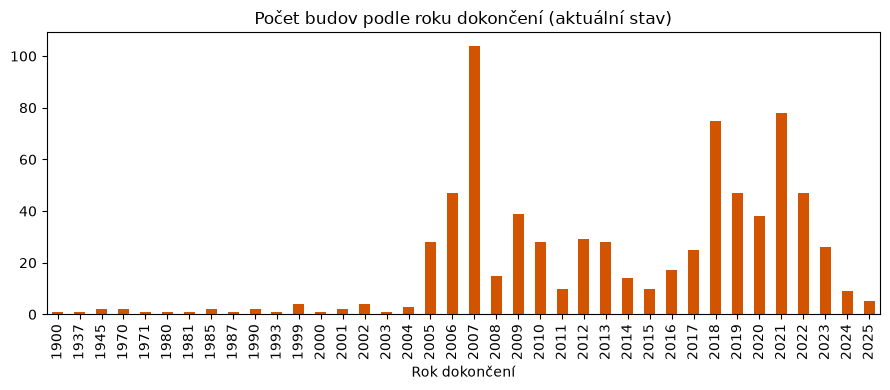

In [190]:
# Aktuálně platné verze = nejnovější PlatiOd pro každý objekt
latest_idx = df_so.groupby(kod_col)[platiOd_col].idxmax()
df_so_aktualni = df_so.loc[latest_idx]
print("Počet aktuálně platných stavebních objektů:", len(df_so_aktualni))

# Rok dokončení aktuálně platných budov (vývoj zástavby v čase)
if "Dokonceni" in df_so_aktualni.columns:
    dokonceni_rok = df_so_aktualni["Dokonceni"].dropna().dt.year
    fig, ax = plt.subplots(figsize=(9, 4))
    dokonceni_rok.value_counts().sort_index().plot(kind="bar", ax=ax, color="#d35400")
    ax.set_title("Počet budov podle roku dokončení (aktuální stav)")
    ax.set_xlabel("Rok dokončení")
    plt.tight_layout()
    plt.show()


## 7. Kontrola konzistence a kvality dat

- Kontrola duplicitních `_gml_id` (mělo by být unikátní)
- Kontrola logiky `PlatiOd <= PlatiDo`
- Kontrola špatně zadaných stavebně technických atributů

In [196]:
# Unikátnost ID
duplicidy = df_so['_gml_id'].duplicated().sum()
print(f"\nDuplicitní gml:id: {duplicidy}")

# Časové kontroly (PlatiOd, PlatiDo)
nelogicke_platnost = df_so[df_so[platiOd_col] > df_so[platiDo_col]]
print(f"Záznamy, kde PlatiOd > PlatiDo: {len(nelogicke_platnost)}")

if "Dokonceni" in df_so.columns:
    dokonceni_dt = pd.to_datetime(df_so["Dokonceni"], errors='coerce')
    v_budoucnu = df_so[dokonceni_dt > pd.Timestamp.now()]
    print(f"Budovy s datem dokončení v budoucnosti: {len(v_budoucnu)}")


# Validace stavebně-technických atributů 
if "PocetPodlazi" in df_so.columns:
    podlazi_numeric = pd.to_numeric(df_so["PocetPodlazi"], errors='coerce')
    neplatna_podlazi = df_so[podlazi_numeric <= 0]
    print(f"Objekty s počtem podlaží <= 0: {len(neplatna_podlazi)}")
    neplatna_podlazi = df_so[podlazi_numeric > 50]
    print(f"Objekty s počtem podlaží > 50: {len(neplatna_podlazi)}")

if "ZastavenaPlocha" in df_so.columns:
    plocha_numeric = pd.to_numeric(df_so["ZastavenaPlocha"], errors='coerce')
    neplatna_plocha = df_so[plocha_numeric <= 0]
    print(f"Objekty se zastavěnou plochou <= 0 m²: {len(neplatna_plocha)}")



Duplicitní gml:id: 0
Záznamy, kde PlatiOd > PlatiDo: 0
Budovy s datem dokončení v budoucnosti: 0
Objekty s počtem podlaží <= 0: 0
Objekty s počtem podlaží > 50: 1
Objekty se zastavěnou plochou <= 0 m²: 0


## 8. Souhrnná profilovací tabulka (export do CSV)

Vytvoří jednu přehlednou tabulku pro každou entitu: název sloupce, datový typ,
počet/procento chybějících hodnot, počet unikátních hodnot a ukázkovou hodnotu.
Tabulky se uloží do `profiling_<entita>.csv`.

In [199]:
def build_profile_table(df):
    rows = []
    for col in df.columns:
        non_null = df[col].dropna()
        sample = non_null.iloc[0] if len(non_null) else None
        rows.append({
            "sloupec": col,
            "dtype": str(df[col].dtype),
            "pocet_hodnot": len(df) - df[col].isna().sum(),
            "chybi_pocet": df[col].isna().sum(),
            "chybi_procent": round(df[col].isna().mean() * 100, 1),
            "pocet_unikatnich": df[col].nunique(dropna=True),
            "ukazka_hodnoty": sample,
        })
    return pd.DataFrame(rows).sort_values("chybi_procent", ascending=False)

profile_tables = {}
for name, df in dfs.items():
    prof = build_profile_table(df)
    profile_tables[name] = prof
    out_path = f"profiling_{name}.csv"
    prof.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"Uloženo: {out_path}  ({len(prof)} sloupců)")

profile_tables["StavebniObjekty"]


Uloženo: profiling_Obce.csv  (17 sloupců)
Uloženo: profiling_CastiObci.csv  (7 sloupců)
Uloženo: profiling_Zsj.csv  (10 sloupců)
Uloženo: profiling_Ulice.csv  (8 sloupců)
Uloženo: profiling_StavebniObjekty.csv  (24 sloupců)
Uloženo: profiling_AdresniMista.csv  (10 sloupců)


,sloupec,dtype,pocet_hodnot,chybi_pocet,chybi_procent,pocet_unikatnich,ukazka_hodnoty
19,IsknBudovaId,str,2,2106,99.9,2,381052210
18,Geometrie,str,320,1788,84.8,315,POINT (-756761.77 -1044034.95)
21,Dokonceni,datetime64[us],1143,965,45.8,366,1981-04-18 00:00:00
23,PodlahovaPlocha,float64,1223,885,42.0,251,682.0
22,ObestavenyProstor,float64,1290,818,38.8,411,2096.0
20,ZastavenaPlocha,float64,1364,744,35.3,215,199.0
15,DruhKonstrukceKod,str,1521,587,27.8,8,10
17,VybaveniVytahemKod,str,1552,556,26.4,3,9
16,PocetPodlazi,float64,1704,404,19.2,7,1.0
11,PripojeniPlynKod,str,1874,234,11.1,5,8
